### Piotr Przymus 127902
# Laboratorium 3: regresja liniowa prosta

## Zadanie 1

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           6.69e-34
Time:                        03:29:32   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

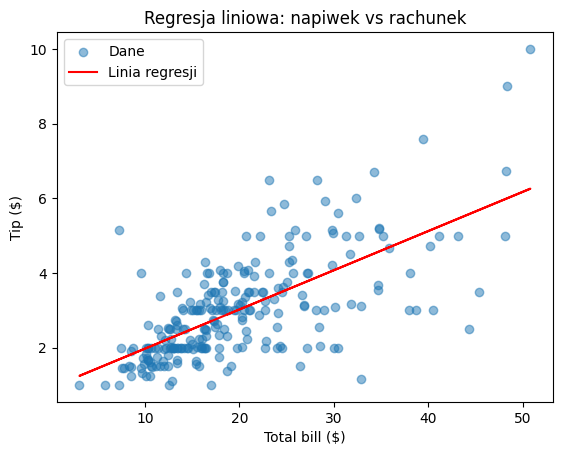

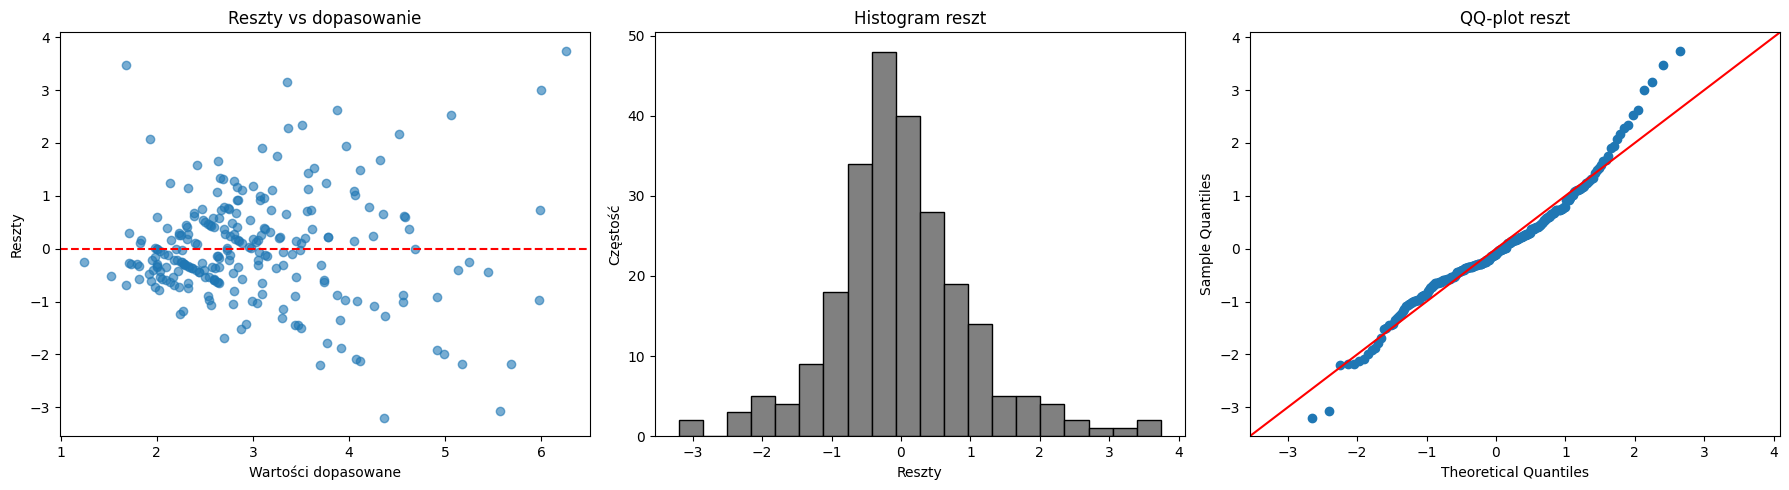

In [12]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# Wczytanie danych
tips = sns.load_dataset("tips")

# Przygotowanie zmiennych
y = tips["tip"]
X = tips["total_bill"]
X = sm.add_constant(X) #

# Dopasowanie modelu
model = sm.OLS(y, X).fit()
print(model.summary())

# Wizualizacja
plt.scatter(tips["total_bill"], tips["tip"], alpha=0.5, label="Dane")
plt.plot(tips["total_bill"], model.predict(X), color="red", label="Linia regresji")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)")
plt.title("Regresja liniowa: napiwek vs rachunek")
plt.legend()
plt.show()

# Diagnostyka reszt: scatter, histogram i QQ-plot
residuals = model.resid
fitted = model.fittedvalues
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(fitted, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Wartości dopasowane")
axes[0].set_ylabel("Reszty")
axes[0].set_title("Reszty vs dopasowanie")

axes[1].hist(residuals, bins=20, color='gray', edgecolor='black')
axes[1].set_title("Histogram reszt")
axes[1].set_xlabel("Reszty")
axes[1].set_ylabel("Częstość")

sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("QQ-plot reszt")

plt.tight_layout()
plt.show()

1. Interpretacja modelu

Pytanie: Co oznacza wartość współczynnika β1 w tym modelu?
- Odpowiedź: Współczynnik β1 informuje o oczekiwanej średniej zmiany napiwku przy wzroście rachunku o 1 jednostkę (dolar).

Pytanie: Jak interpretować wyraz wolny β0 w kontekście danych o rachunkach i napiwkach?
- Odpowiedź: Wyraz wolny β0 to przewidywana wartość napiwku przy rachunku równym 0; praktycznie jest to punkt przecięcia z osią Y.

Pytanie: Czy wyraz wolny β0 ma w tym przypadku sens praktyczny? Dlaczego tak/nie?
- Odpowiedź: Nie ma sensu praktycznego, ponieważ rachunek równy 0 nie powinien występować.

2. Statystyki dopasowania

Pytanie: Jak interpretować wartość R² otrzymaną w podsumowaniu modelu?
- Odpowiedź: R² = 0.457 oznacza, że około 45.7% zmienności napiwków (`tip`) jest wyjaśnione przez zmienną `total_bill`. To umiarkowane dopasowanie - model wyjaśnia istotną część wariancji, ale ponad połowa wariancji pozostaje niewyjaśniona (wyjaśnione przez inne czynniki).

Pytanie: Co oznacza wysoka wartość p-value przy danym współczynniku?
- Odpowiedź: Wysoka p-value sugeruje brak dowodów na to, by współczynnik był istotnie różny od zera - związek między zmienną objaśniającą (predyktorem) a zmienną zależną jest statystycznie nieistotny.

Pytanie: Jakie wnioski można wyciągnąć, jeśli test F wskazuje na istotność całego modelu?
- Odpowiedź: Istotny test F oznacza, że co najmniej jeden z predyktorów ma istotny wpływ na zmienną zależną - model jako całość jest użyteczny. W wynikach mamy F-statistic = 203.4 (model wyjaśnia znaczną część zmienności, zmienne objaśniające mają wpływ na model) i Prob (F-statistic) ≈ 6.69e-34 (odrzucamy hipotezę zerową, model jest istotny statystycznie).

3. Reszty i diagnostyka

Pytanie: Jak sprawdzić, czy reszty mają rozkład normalny w tym przykładzie?
- Odpowiedź: Sprawdzić to można przy pomocy QQ-plota reszt, histogramu reszt (co też zrobiłem) lub testów (np. Shapiro-Wilka).

Pytanie: Co by oznaczało, gdyby reszty układały się w „kształt lejka” na wykresie reszt względem wartości dopasowanych?
- Odpowiedź: Kształt lejka sugerowałby heteroscedastyczność - wariancja błędów zależy od poziomu predykcji.

Pytanie: Jakie wnioski można wyciągnąć, jeśli QQ-plot reszt znacząco odbiega od linii 45°?
- Odpowiedź: Odbiegnięcie QQ-plota wskazuje na odchylenia od normalności reszt, co może wpływać na wiarygodność wniosków z modelu.

4. Rozszerzenie modelu

Pytanie: Jak zmieniłby się model, gdybyśmy uwzględnili także zmienną size (liczbę osób przy stoliku)?
- Odpowiedź: Model stałby się wieloraki: `tip ~ total_bill + size`; size mógłby wyjaśniać dodatkową część wariancji tip.

Pytanie: Jak można uwzględnić zmienne kategoryczne, takie jak day lub time, w modelu regresji liniowej?
- Odpowiedź: Np. poprzez zastosowanie one-hot encoding.

Pytanie: Czy włączenie dodatkowych zmiennych zawsze poprawia dopasowanie modelu? Uzasadnij.
- Odpowiedź: Nie zawsze - dodatkowe zmienne mogą prowadzić do przeuczenia; warto sprawdzać wkład zmiennych i stosować walidację.

5. Praktyczne aspekty

Pytanie: Jak można wykorzystać taki model w praktyce np. w restauracji?
- Odpowiedź: Do prognozowania napiwków, analizowania zależności przychodów i podejmowania decyzji operacyjnych.

Pytanie: Jakie ograniczenia ma ten model (tylko tip ~ total_bill)?
- Odpowiedź: Pomija część czynników np. jakość obsługi lub porę dnia, co ogranicza trafność predykcji.

Pytanie: Jakie inne czynniki mogłyby wpływać na wysokość napiwku, a nie są ujęte w tym modelu?
- Odpowiedź: Jak wyżej - jakość obsługi, liczba osób, pora dnia, dzień tygodnia, promocje, lokalizacja, zwyczaje klientów.


## Zadanie 2: własny przykład regresji prostej

Jako zbiór wybrałem `mpg` z Seaborn. Sprawdzam zależność między zużyciem paliwa `mpg` (zmienna objaśniana) a mocą silnika `horsepower` (zmienna objaśniająca).

In [13]:
mpg = sns.load_dataset("mpg")
mpg_clean = mpg[["mpg", "horsepower"]].dropna()

y_mpg = mpg_clean["mpg"]
X_mpg = sm.add_constant(mpg_clean["horsepower"])
model_mpg = sm.OLS(y_mpg, X_mpg).fit()

print(model_mpg.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           7.03e-81
Time:                        03:29:33   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

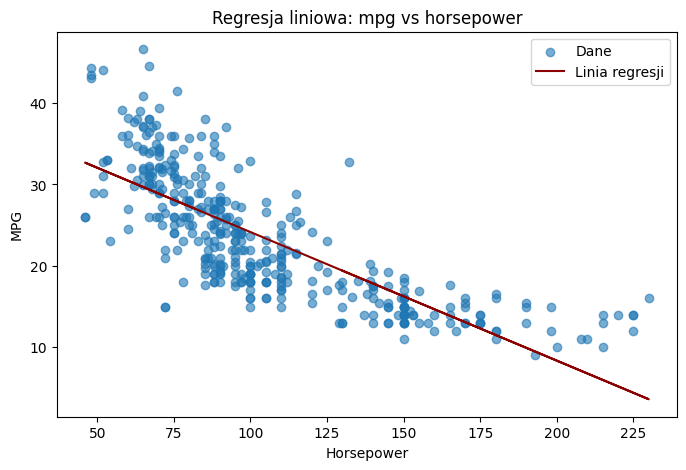

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(mpg_clean["horsepower"], mpg_clean["mpg"], alpha=0.6, label="Dane")
plt.plot(mpg_clean["horsepower"], model_mpg.predict(X_mpg), color="darkred", label="Linia regresji")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regresja liniowa: mpg vs horsepower")
plt.legend()
plt.show()

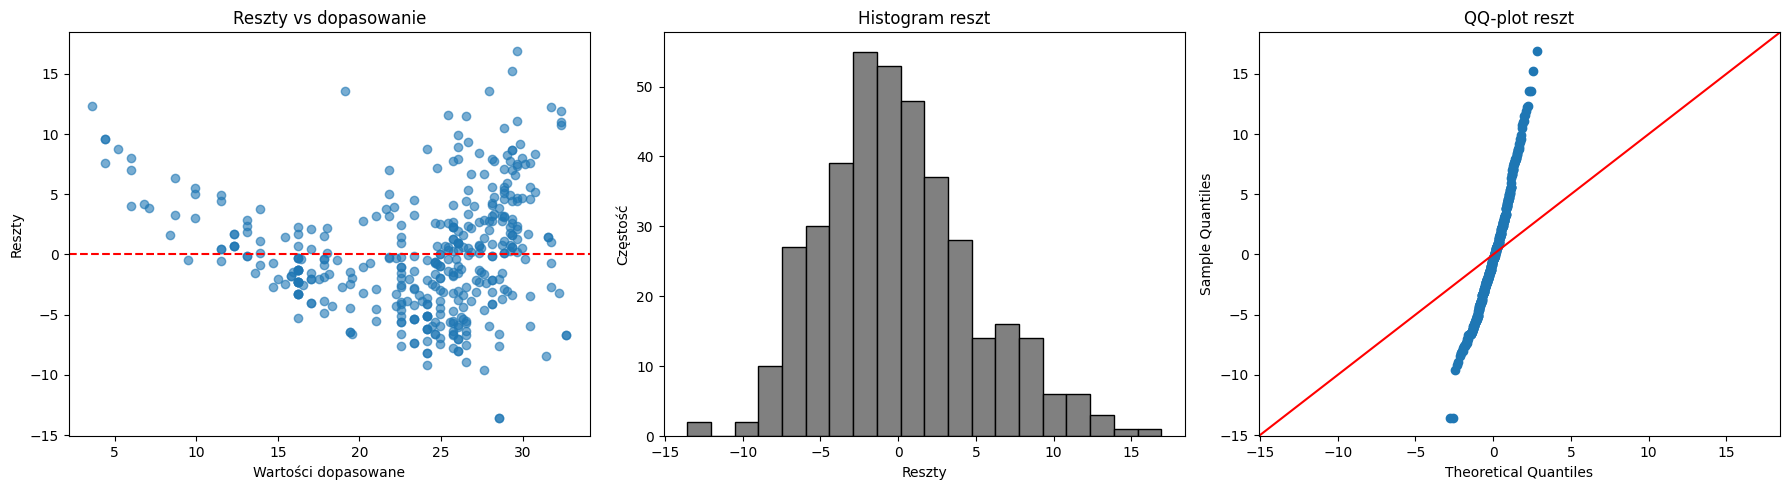

In [15]:
residuals_mpg = model_mpg.resid
fitted_mpg = model_mpg.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(fitted_mpg, residuals_mpg, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Wartości dopasowane")
axes[0].set_ylabel("Reszty")
axes[0].set_title("Reszty vs dopasowanie")

axes[1].hist(residuals_mpg, bins=20, color='gray', edgecolor='black')
axes[1].set_title("Histogram reszt")
axes[1].set_xlabel("Reszty")
axes[1].set_ylabel("Częstość")

sm.qqplot(residuals_mpg, line="45", ax=axes[2])
axes[2].set_title("QQ-plot reszt")

plt.tight_layout()
plt.show()

Wykorzystałem zbiór danych `mpg` w celu zbudowania modelu regresji liniowej prostej. Jako zmienną zależną przyjęto zużycie paliwa (`mpg`), natomiast zmienną objaśniającą była moc silnika (`horsepower`). Przed analizą usunięto brakujące obserwacje.

Dopasowany model regresji liniowej wskazuje na istotną statystycznie zależność między zmiennymi. Współczynnik przy zmiennej `horsepower` jest ujemny, co oznacza, że wraz ze wzrostem mocy silnika przeciętne zużycie paliwa maleje. Wynik ten jest zgodny z intuicją - samochody o większej mocy są zazwyczaj mniej ekonomiczne.

Wartość współczynnika determinacji R² na poziomie około 0.61 oznacza, że model wyjaśnia około 61% zmienności zmiennej `mpg`, co można uznać za stosunkowo dobre dopasowanie jak na prosty model liniowy z jedną zmienną objaśniającą.

W ramach diagnostyki przeanalizowano reszty modelu, czyli różnice między wartościami rzeczywistymi a wartościami przewidywanymi przez model. Wykres reszt względem wartości dopasowanych nie wskazuje jednoznacznie na silne naruszenie założeń (kształt nie jest do końca lejkowaty), jednak QQ-plot pokazuje pewne odchylenia od rozkładu normalnego, co potwierdza histogram oraz wyniki testów statystycznych.

Odchylenia te mogą wynikać z faktu, że rzeczywista zależność między zmiennymi nie jest w pełni liniowa. Mimo to model dobrze oddaje ogólny trend w danych i pozwala na interpretację zależności między mocą silnika a zużyciem paliwa.

Podsumowując, zbudowany model regresji liniowej prostej jest poprawny i w pewnym stopniu użyteczny do analizy zależności między zmiennymi, choć nie spełnia w pełni wszystkich klasycznych założeń regresji liniowej.
